In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import GridSearchCV, KFold
import statsmodels.api as sm

In [ ]:
df = pd.read_csv('Student-Employability-Datasets.csv') #import data set
df.head(5)

,Name of Student,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF-CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,Student Performance Rating,CLASS
0,Student 1,4,5,4,5,5,5,5,5,Employable
1,Student 2,4,4,4,4,4,4,3,5,Employable
2,Student 3,4,3,3,3,3,3,2,5,LessEmployable
3,Student 4,3,3,3,2,3,3,3,5,LessEmployable
4,Student 5,4,4,3,3,4,4,3,5,Employable


In [ ]:
print(df.columns) #display basic information to get to know the data set
print(df.info())

Index(['Name of Student', 'GENERAL APPEARANCE', 'MANNER OF SPEAKING',
       'PHYSICAL CONDITION', 'MENTAL ALERTNESS', 'SELF-CONFIDENCE',
       'ABILITY TO PRESENT IDEAS', 'COMMUNICATION SKILLS',
       'Student Performance Rating', 'CLASS'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2982 entries, 0 to 2981
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Name of Student             2982 non-null   object
 1   GENERAL APPEARANCE          2982 non-null   int64 
 2   MANNER OF SPEAKING          2982 non-null   int64 
 3   PHYSICAL CONDITION          2982 non-null   int64 
 4   MENTAL ALERTNESS            2982 non-null   int64 
 5   SELF-CONFIDENCE             2982 non-null   int64 
 6   ABILITY TO PRESENT IDEAS    2982 non-null   int64 
 7   COMMUNICATION SKILLS        2982 non-null   int64 
 8   Student Performance Rating  2982 non-null   int64 
 9   CLASS 

In [ ]:
print(df['CLASS'].value_counts()) #Explore categories in the variable that will be our target


CLASS
Employable        1729
LessEmployable    1253
Name: count, dtype: int64


In [ ]:
df.CLASS = df.CLASS.map({'Employable':0, 'LessEmployable':1}) #code bot categories with binary values (0 & 1)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2982 entries, 0 to 2981
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Name of Student             2982 non-null   object
 1   GENERAL APPEARANCE          2982 non-null   int64 
 2   MANNER OF SPEAKING          2982 non-null   int64 
 3   PHYSICAL CONDITION          2982 non-null   int64 
 4   MENTAL ALERTNESS            2982 non-null   int64 
 5   SELF-CONFIDENCE             2982 non-null   int64 
 6   ABILITY TO PRESENT IDEAS    2982 non-null   int64 
 7   COMMUNICATION SKILLS        2982 non-null   int64 
 8   Student Performance Rating  2982 non-null   int64 
 9   CLASS                       2982 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 233.1+ KB
None


In [ ]:
df = df.drop('Name of Student', axis=1) #remove the "Name of students" column since it is useless
print(df.columns)


Index(['GENERAL APPEARANCE', 'MANNER OF SPEAKING', 'PHYSICAL CONDITION',
       'MENTAL ALERTNESS', 'SELF-CONFIDENCE', 'ABILITY TO PRESENT IDEAS',
       'COMMUNICATION SKILLS', 'Student Performance Rating', 'CLASS'],
      dtype='object')


In [ ]:
df.describe() #get more basic statistics form each column to study their behavior

,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF-CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,Student Performance Rating,CLASS
count,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000,2982.000000
mean,4.246814,3.884641,3.972166,3.962777,3.910798,3.813883,3.525486,4.610664,0.420188
std,0.678501,0.757013,0.744135,0.781982,0.807602,0.739390,0.743881,0.692845,0.493672
min,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,0.000000
25%,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,0.000000
50%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,0.000000
75%,5.000000,4.000000,5.000000,5.000000,5.000000,4.000000,4.000000,5.000000,1.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000


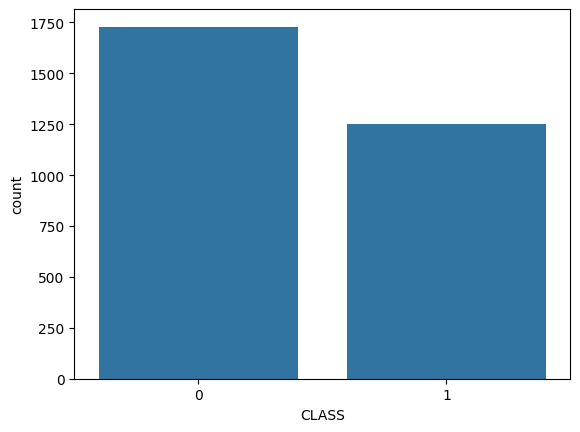

In [ ]:
sns.countplot(x='CLASS', data=df) #see graphicly the diference between categories in our target
plt.show()

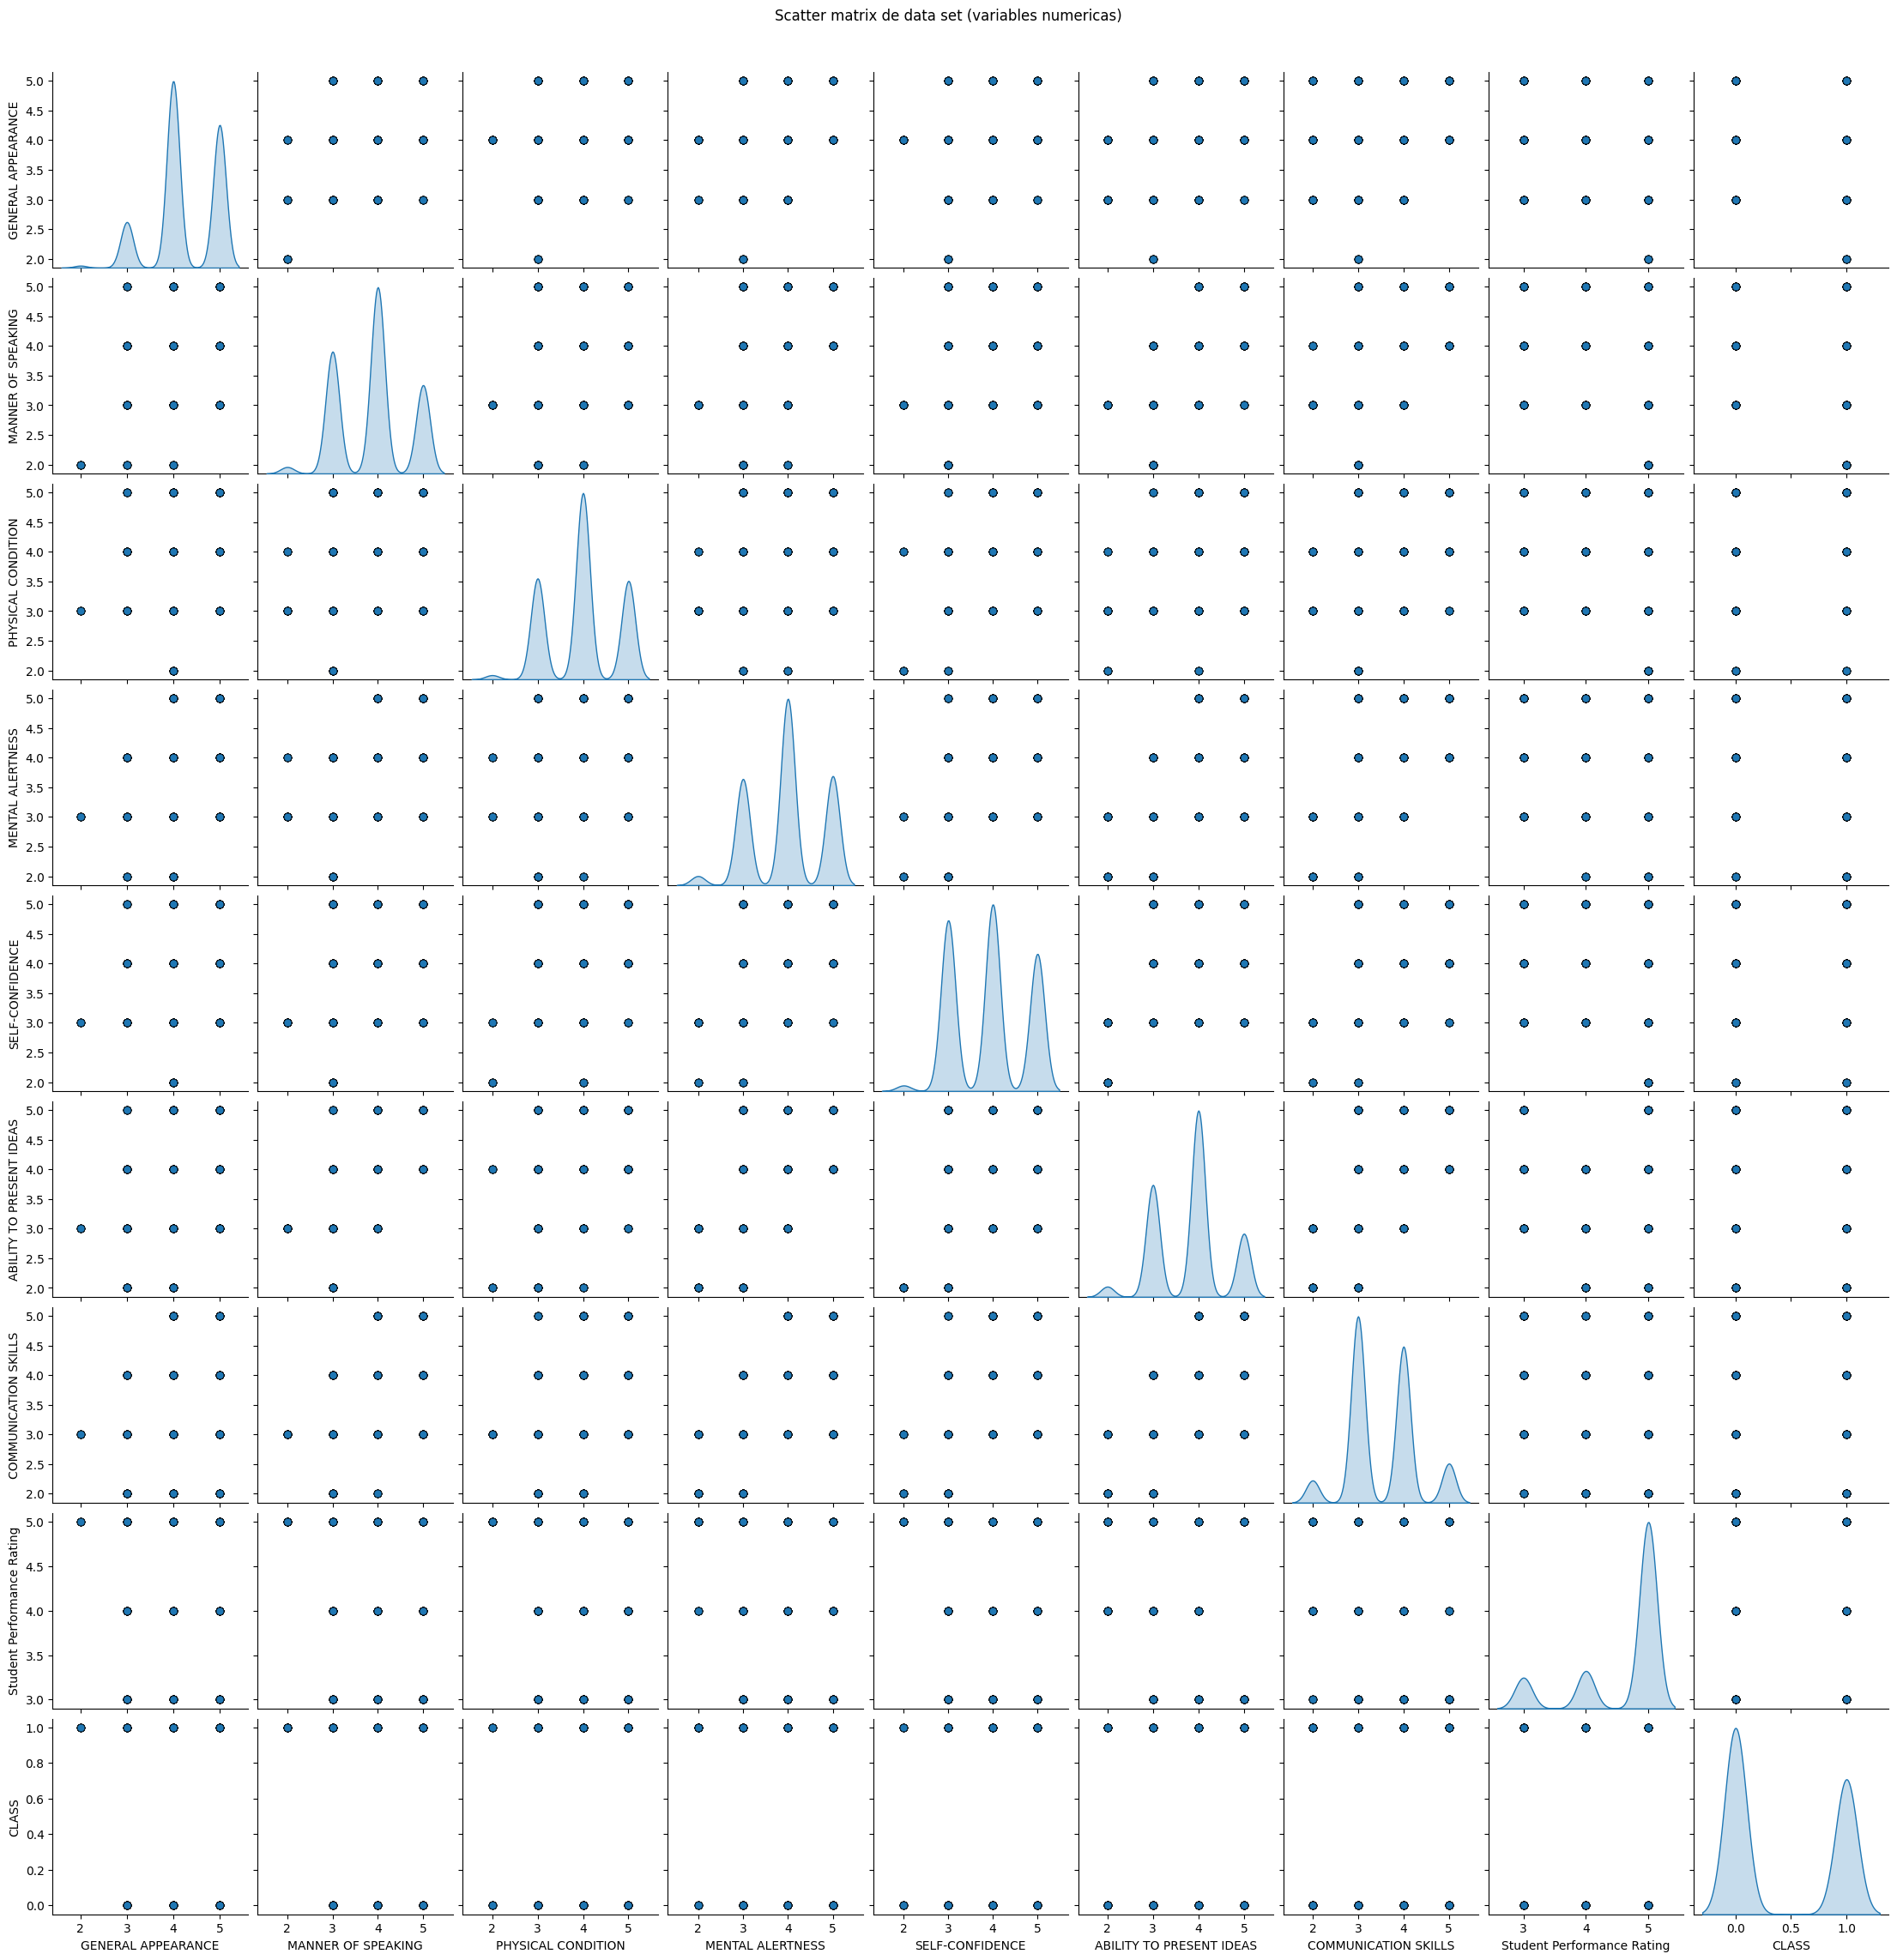

In [ ]:
#Plot a scatter matrix to spot posible multicorrelation cases
sns.pairplot(
    df,
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'k'}
)

# Add a title
plt.suptitle("Scatter matrix de data set (variables numericas)", y=1.02)
plt.show()

In [ ]:
#Eventhough there were no irregulariteis in the scatter matrix we still want to get the VIF data from each variable to make sure there is no multicorreleation
X = df[['GENERAL APPEARANCE','MANNER OF SPEAKING','PHYSICAL CONDITION','MENTAL ALERTNESS', 'SELF-CONFIDENCE', 'ABILITY TO PRESENT IDEAS',
        'COMMUNICATION SKILLS', 'Student Performance Rating']]

X = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)

                     Variable         VIF
0                       const  101.298223
1          GENERAL APPEARANCE    1.465999
2          MANNER OF SPEAKING    2.451950
3          PHYSICAL CONDITION    2.155922
4            MENTAL ALERTNESS    2.681052
5             SELF-CONFIDENCE    2.471830
6    ABILITY TO PRESENT IDEAS    2.895072
7        COMMUNICATION SKILLS    2.127699
8  Student Performance Rating    1.124001


In [ ]:
#split in train - test with a 80% - 20% portion
X = df[['GENERAL APPEARANCE','MANNER OF SPEAKING','PHYSICAL CONDITION','MENTAL ALERTNESS', 'SELF-CONFIDENCE', 'ABILITY TO PRESENT IDEAS',
        'COMMUNICATION SKILLS', 'Student Performance Rating']]
y = df['CLASS']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(np.shape(X_train))
print(np.shape(X_test))

(2385, 8)
(597, 8)


Prediccion  [0 1 1 1 1 1 0 0 0 1 0 0 1 0 0 1 1 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 1 1 1 0 0
 0 0 1 0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 1 0 0 1 1 0 0 1 0 1 0 1 1 0 1 1 1 0 1
 0 1 1 0 0 1 1 1 1 1 1 0 0 1 0 0 0 1 0 1 0 0 1 0 0 1 0 1 1 1 1 0 0 0 1 1 0
 1 1 0 1 0 1 1 0 0 1 0 0 1 1 1 1 1 1 0 1 0 0 0 0 1 1 1 1 0 1 0 0 1 0 1 1 1
 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 1 1 1 1 1 0 0 1 1 1 0 0 0 0 0 0 1
 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 0 0
 1 0 0 0 1 0 1 0 1 1 0 0 1 0 1 0 1 0 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 1 0 1 1
 0 0 0 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0 1 0 1 1 0 1 0
 0 0 1 1 1 1 1 1 0 0 1 0 1 1 0 0 0 1 1 1 0 1 0 0 0 0 1 0 1 0 0 1 0 1 1 1 0
 0 1 0 1 0 0 0 0 1 0 0 1 1 0 0 0 1 0 1 1 0 0 0 0 0 1 1 0 1 0 0 1 1 1 0 0 1
 1 0 0 0 0 0 0 1 0 1 0 1 1 1 1 0 1 1 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 0 1 1
 0 0 1 1 1 0 0 0 1 0 1 1 0 1 0 0 1 0 1 1 1 0 1 1 0 0 0 0 1 1 1 0 1 0 0 1 0
 1 1 0 1 0 1 1 1 0 1 0 0 0 1 0 0 1 1 0 1 1 0 0 1 0 1 1 0 1 1 1 0 0 1 0 0 0
 1 0 0 1 0 0 

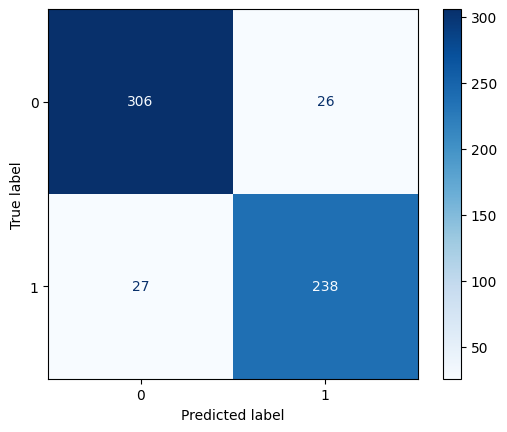

Classification Report for Random Forest:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92       332
           1       0.90      0.90      0.90       265

    accuracy                           0.91       597
   macro avg       0.91      0.91      0.91       597
weighted avg       0.91      0.91      0.91       597



In [ ]:
#train our random forest model without looking for the best parameters
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
print('Prediccion ', y_pred)
print('Especie real', np.reshape(y_test,(1,597)))

cm = confusion_matrix(y_test, y_pred, labels=rf.classes_) # plot the confusion matrix to see graphicly how the model performed
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

report_rf = classification_report(y_test, y_pred) #print out report to see scores
print("Classification Report for Random Forest:\n", report_rf)

Best Hyperparameters for Random Forest: {'bootstrap': True, 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
Predictions:  [0 1 1 1 1 1 0 0 0 1 0 0 1 0 0 1 1 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 1 1 1 0 0
 0 0 1 0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 1 1 1 0 1
 0 1 1 0 0 1 1 1 1 1 1 0 0 1 0 0 0 1 0 1 0 0 1 0 0 1 0 1 1 1 1 0 0 0 1 1 0
 1 1 0 1 0 1 1 0 0 1 0 0 1 1 1 1 1 1 0 1 0 0 0 0 1 1 1 1 0 1 0 0 1 0 1 1 1
 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 1 1 1 1 1 0 0 1 1 1 0 0 0 0 0 0 1
 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 0 0
 1 0 0 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 1 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 0 1 1
 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0 1 0 1 1 0 1 0
 0 0 0 1 1 1 1 1 0 0 1 0 1 1 0 0 0 1 1 1 0 1 0 0 0 0 1 0 1 0 0 1 0 1 1 1 0
 0 1 0 1 0 0 0 0 1 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 1 1 1 0 0 1
 1 0 0 0 0 0 0 1 0 1 0 1 1 1 1 0 1 1 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 

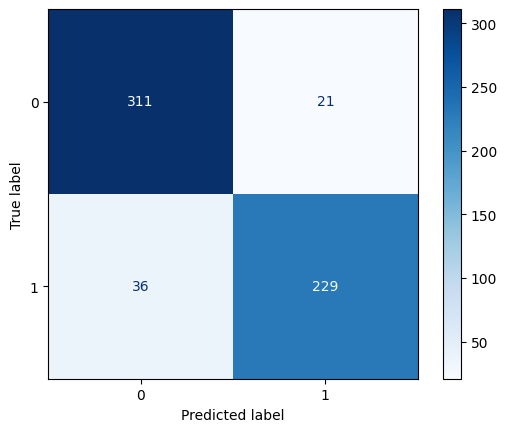

Classification Report for Random Forest:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92       332
           1       0.92      0.86      0.89       265

    accuracy                           0.90       597
   macro avg       0.91      0.90      0.90       597
weighted avg       0.91      0.90      0.90       597



In [ ]:
#train our random forest model looking for the best parameters using Grid Search
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1) #create 5 k-folds
grid_search_rf.fit(X_train, y_train)
best_rf = grid_search_rf.best_estimator_
print("Best Hyperparameters for Random Forest:", grid_search_rf.best_params_) #get the best hyper parameters
y_pred_rf = best_rf.predict(X_test)
print("Predictions: ", y_pred_rf)
print(y_pred_rf.shape)
print("Actual: ",  np.reshape(y_test,(1,597)))

cm = confusion_matrix(y_test, y_pred_rf) # plot the confusion matrix to see graphicly how the model performed
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

report_rf = classification_report(y_test, y_pred_rf) # print out report to see scores
print("Classification Report for Random Forest:\n", report_rf)